In [1]:
import os 
from pathlib import Path
import shutil
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import re
from torchvision import transforms
from sklearn.model_selection import train_test_split
import json
from dataclasses import dataclass, asdict
import torch 
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.metrics import recall_score, classification_report
from tqdm import tqdm 
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Load dataset from cloud storage and unzip in local virtual space 
!cp '/content/drive/MyDrive/Deep Learning Datasets /UTK FACE.zip' /content/
!unzip -q '/content/UTK FACE.zip' -d /content/local_dataset/

In [3]:
#Image Preprocessing 
path = '/content/local_dataset/'
data= []
age_group = []
renamed_count = 0
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.jpg.chip.jpg'):
            old_name = os.path.join(root, file)
            new_name = file.replace('.chip.jpg', '')
            new_path = os.path.join(root,new_name)

            try:
                os.rename(old_name, new_path)
                renamed_count += 1
            except OSError as e:
                print(f"Error occurred while renaming {old_name}: {e}")
                
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(('.jpg','.jpeg','.png')):   
           match = re.match(r"(\d+)_", file)
           if match:
                # Assign label to images in the data: #1 for child and #2 for adult
                age = int(match.group(1))
           if age <= 13:
                age_group.append(1)
           elif age >13:
                age_group.append(0) 
           data.append(os.path.join(root, file))

In [ ]:
#Check for imbalance in the dataset 
child_data = sum([1 for i in age_group if i == 1])
adult_data = len(age_group) - child_data
print(child_data, adult_data)

13648 53328


(np.float64(-0.5), np.float64(199.5), np.float64(199.5), np.float64(-0.5))

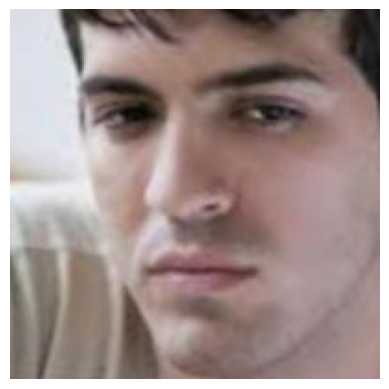

In [5]:
# Append the scipts directory to system path so that script in folder can be callable as Module
import sys
sys.path.append('/content/drive/My Drive/Deep Learning Models /UnderAgeFacePrivacy')
from src.Models import Custom_cnn
from src.Registry import yaml_loader, model_registry

sample_img = data[10]
opened_img = Image.open(sample_img)
opened_img.show()
plt.imshow(opened_img)
plt.axis('off')

In [ ]:
class CustomDataset(Dataset):
    def __init__(self,data,label):
        self.data = data 
        self.label = label
        self.transform = transforms.Compose([transforms.Lambda(lambda img: img.convert('RGB')),
                                             transforms.Resize((224,224)),
                                             transforms.ToTensor(),
                                             transforms.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])])
    def __len__(self):
        return len(self.data)
    def __getitem__ (self, idx):
        img_path = self.data[idx]
        img_label = self.label[idx]
        img = Image.open(img_path)
        img = self.transform(img)
        return img, img_label
    
def Accuracy(y_pred,y_true):
    y_pred = torch.argmax(y_pred, dim=1)
    correct = (y_pred == y_true).sum().item()
    total = len(y_true)
    accuracy = correct / total
    return accuracy

def compute_recall_metrics (preds, labels):
    child_recall = recall_score(labels,preds,pos_label=1)
    adult_recall = recall_score(labels,preds,pos_label=0)
    return child_recall, adult_recall

In [7]:
config_path = '/content/drive/My Drive/Deep Learning Models /UnderAgeFacePrivacy/config/config.yaml'
cfg = yaml_loader(config_path)
train_data, test_data, train_labels, test_labels = train_test_split(data, age_group, test_size = 0.2, random_state= 42)
raw_weights = compute_class_weight(class_weight= 'balanced',
                                   classes= np.unique(train_labels),
                                   y= train_labels)
class_weights = torch.tensor(raw_weights,dtype= torch.float32)

In [8]:
data_train = CustomDataset(train_data,train_labels)
data_test = CustomDataset(test_data,test_labels)
Batch_size = cfg['training']['batch_size']
Num_worker = cfg['training']['num_worker']
train_dataloader  = DataLoader(data_train, batch_size = Batch_size, shuffle= True, num_workers=Num_worker, pin_memory= True)
test_dataloader = DataLoader(data_test, batch_size = Batch_size, shuffle= False, num_workers= Num_worker, pin_memory=True)

In [9]:
model, input_size = model_registry(cfg)
device = cfg['training']['device']
model = model.to(device)
class_weights = class_weights.to(device)
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr= cfg['training']['learning_rate'])
epochs = cfg['training']['num_epochs']

best_child_recall = 0
for epoch in tqdm(range(epochs)):
    model.train()
    running_loss = 0.0
    running_accuracy = 0.0
    all_pred = []
    all_true_label = []
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        running_accuracy += Accuracy(outputs, labels)
        optimizer.step()
        running_loss += loss.item()
        pred = torch.argmax(outputs,dim=1).cpu().tolist()
        all_pred.extend(pred)
        all_true_label.extend(labels.cpu().tolist())
    epoch_loss = running_loss / len(train_dataloader)
    epoch_accuracy = running_accuracy / len(train_dataloader)
    child_recall, adult_recall = compute_recall_metrics(all_pred,all_true_label)

    model.eval()
    with torch.no_grad():
        test_loss = 0.0
        test_accuracy = 0.0
        all_test_pred = []
        all_test_true_label = []
        for images, labels in test_dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            test_loss += loss.item()
            test_accuracy += Accuracy(outputs, labels)
            test_pred = torch.argmax(outputs, dim=1).cpu().tolist()
            all_test_pred.extend(test_pred)
            all_test_true_label.extend(labels.cpu().tolist())
    test_loss /= len(test_dataloader)
    test_accuracy/= len(test_dataloader)
    test_child_recall, test_adult_recall = compute_recall_metrics(all_test_pred,all_test_true_label)
    print('-' * 50)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Test Loss: {test_loss:.4f}")
    print(f"Epoch [{epoch+1}/{epochs}], Accuracy: {epoch_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")
    print(f"Epoch [{epoch+1}/{epochs}], Child Recall: {child_recall:.4f}, Test child recall: {test_child_recall:.4f}")
    print(f"Epoch [{epoch+1}/{epochs}], Adult Recall: {adult_recall:.4f}, Test Adult recall: {test_adult_recall:.4f}")

    if test_child_recall > best_child_recall:
       best_child_recall = test_child_recall
       checkpoint = {
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch + 1,
            'test_child_recall': test_child_recall,
            'test_loss': test_loss
        }
       model_save_path = '/content/drive/My Drive/Deep Learning Models /UnderAgeFacePrivacy/model.pt'
       torch.save(checkpoint, model_save_path)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 222MB/s]
  0%|          | 0/10 [00:00<?, ?it/s]

--------------------------------------------------
Epoch [1/10], Loss: 0.3064, Test Loss: 0.2454
Epoch [1/10], Accuracy: 0.8905, Test Accuracy: 0.8970
Epoch [1/10], Child Recall: 0.8409, Test child recall: 0.9157
Epoch [1/10], Adult Recall: 0.9032, Test Adult recall: 0.8920


 10%|█         | 1/10 [01:33<14:00, 93.42s/it]

--------------------------------------------------
Epoch [2/10], Loss: 0.2467, Test Loss: 0.2454
Epoch [2/10], Accuracy: 0.9116, Test Accuracy: 0.8790
Epoch [2/10], Child Recall: 0.8742, Test child recall: 0.9395
Epoch [2/10], Adult Recall: 0.9211, Test Adult recall: 0.8631


...

--------------------------------------------------
Epoch [8/10], Loss: 0.2205, Test Loss: 0.2282
Epoch [8/10], Accuracy: 0.9183, Test Accuracy: 0.9392
Epoch [8/10], Child Recall: 0.8940, Test child recall: 0.8447
Epoch [8/10], Adult Recall: 0.9244, Test Adult recall: 0.9638


 90%|█████████ | 9/10 [13:30<01:29, 89.73s/it]

--------------------------------------------------
Epoch [9/10], Loss: 0.2206, Test Loss: 0.2302
Epoch [9/10], Accuracy: 0.9185, Test Accuracy: 0.9391
Epoch [9/10], Child Recall: 0.8921, Test child recall: 0.8454
Epoch [9/10], Adult Recall: 0.9252, Test Adult recall: 0.9636


100%|██████████| 10/10 [15:00<00:00, 90.02s/it]

--------------------------------------------------
Epoch [10/10], Loss: 0.2180, Test Loss: 0.2089
Epoch [10/10], Accuracy: 0.9205, Test Accuracy: 0.9081
Epoch [10/10], Child Recall: 0.8985, Test child recall: 0.9359
Epoch [10/10], Adult Recall: 0.9261, Test Adult recall: 0.9008


In [10]:
print("\nFinal classification report:")
print(classification_report(all_test_true_label, all_test_pred,
                                    target_names=['adult', 'child']))


Final classification report:
              precision    recall  f1-score   support

       adult       0.98      0.90      0.94     10621
       child       0.71      0.94      0.81      2775

    accuracy                           0.91     13396
   macro avg       0.85      0.92      0.87     13396
weighted avg       0.93      0.91      0.91     13396

